In [2]:
import pandas as pd
df1 = pd.read_excel('_h_batch_process_data.xlsx')
df2 = pd.read_excel('_h_batch_production_data.xlsx')


In [3]:
augmented_data = pd.read_csv('synthetic_process_data.csv')
augmented_data = augmented_data.loc[:, augmented_data.nunique() > 1]

In [4]:
augmented_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Moisture_Content      10000 non-null  float64
 1   Tablet_Weight         10000 non-null  float64
 2   Hardness              10000 non-null  float64
 3   Friability            10000 non-null  float64
 4   Disintegration_Time   10000 non-null  float64
 5   Dissolution_Rate      10000 non-null  float64
 6   Content_Uniformity    10000 non-null  float64
 7   Time_Minutes          10000 non-null  float64
 8   Temperature_C         10000 non-null  float64
 9   Pressure_Bar          10000 non-null  float64
 10  Humidity_Percent      10000 non-null  float64
 11  Motor_Speed_RPM       10000 non-null  float64
 12  Compression_Force_kN  10000 non-null  float64
 13  Flow_Rate_LPM         10000 non-null  float64
 14  Power_Consumption_kW  10000 non-null  float64
 15  Vibration_mm_s        10000 non

In [5]:
# augmented_data.drop('Batch_ID',axis=1,inplace=True)

In [ ]:
#Modified synthetic dataset from random to weighted rships
import numpy as np

# Tablet Weight
augmented_data["Tablet_Weight"] = (
    200
    + 1.2 * augmented_data["Flow_Rate_LPM"]
    - 0.8 * augmented_data["Moisture_Content"]
    + 0.4 * augmented_data["Pressure_Bar"]
    + 0.01 * augmented_data["Motor_Speed_RPM"]
    + np.random.normal(0,0.4,len(augmented_data))
)

# Hardness
augmented_data["Hardness"] = (
    50
    + 2.5 * augmented_data["Compression_Force_kN"]
    + 0.6 * augmented_data["Pressure_Bar"]
    - 1.2 * augmented_data["Moisture_Content"]
    + 0.03 * augmented_data["Motor_Speed_RPM"]
    + np.random.normal(0,0.4,len(augmented_data))
)

# Friability (inverse relation with hardness)
augmented_data["Friability"] = (
    1.5
    - 0.015 * augmented_data["Hardness"]
    + 0.03 * augmented_data["Moisture_Content"]
    + 0.015 * augmented_data["Humidity_Percent"]
    + np.random.normal(0,0.03,len(augmented_data))
)

# Disintegration Time
augmented_data["Disintegration_Time"] = (
    8
    + 0.07 * augmented_data["Moisture_Content"]
    + 0.04 * augmented_data["Tablet_Weight"]
    - 0.06 * augmented_data["Temperature_C"]
    - 0.03 * augmented_data["Compression_Force_kN"]
    + np.random.normal(0,0.5,len(augmented_data))
)

# Dissolution Rate
augmented_data["Dissolution_Rate"] = (
    80
    + 0.35 * augmented_data["Temperature_C"]
    - 0.7 * augmented_data["Hardness"]
    - 0.03 * augmented_data["Disintegration_Time"]
    + np.random.normal(0,0.4,len(augmented_data))
)

# Content Uniformity
augmented_data["Content_Uniformity"] = (
    94
    + 0.05 * augmented_data["Flow_Rate_LPM"]
    - 0.04 * augmented_data["Humidity_Percent"]
    + 0.02 * augmented_data["Pressure_Bar"]
    + np.random.normal(0,0.5,len(augmented_data))
)

# Power Consumption
augmented_data["Power_Consumption_kW"] = (
    0.004 * augmented_data["Motor_Speed_RPM"]
    + 1.2 * augmented_data["Compression_Force_kN"]
    + 0.8 * augmented_data["Pressure_Bar"]
    + 0.4 * augmented_data["Flow_Rate_LPM"]
    + np.random.normal(0,0.5,len(augmented_data))
)

# Machine Vibration
augmented_data["Vibration_mm_s"] = (
    0.006 * augmented_data["Motor_Speed_RPM"]
    + 0.9 * augmented_data["Compression_Force_kN"]
    + 0.5 * augmented_data["Pressure_Bar"]
    + np.random.normal(0,0.3,len(augmented_data))
)

In [ ]:
#Engineered features
import numpy as np

augmented_data["Compression_Load"] = augmented_data["Compression_Force_kN"] * augmented_data["Pressure_Bar"]

augmented_data["Thermal_Energy"] = augmented_data["Temperature_C"] * augmented_data["Time_Minutes"]

augmented_data["Mechanical_Energy"] = augmented_data["Motor_Speed_RPM"] * augmented_data["Compression_Force_kN"]

augmented_data["Hardness_Pressure"] = augmented_data["Compression_Force_kN"] * augmented_data["Pressure_Bar"]

augmented_data["Moisture_Temperature"] = augmented_data["Moisture_Content"] * augmented_data["Temperature_C"]

augmented_data["Speed_Flow"] = augmented_data["Motor_Speed_RPM"] * augmented_data["Flow_Rate_LPM"]


In [ ]:
#removing log features due to it being NaN
augmented_data = augmented_data.drop(['Log_Power', 'Log_Vibration'], axis=1)
augmented_data.isnull().sum()

Moisture_Content        0
Tablet_Weight           0
Hardness                0
Friability              0
Disintegration_Time     0
Dissolution_Rate        0
Content_Uniformity      0
Time_Minutes            0
Temperature_C           0
Pressure_Bar            0
Humidity_Percent        0
Motor_Speed_RPM         0
Compression_Force_kN    0
Flow_Rate_LPM           0
Power_Consumption_kW    0
Vibration_mm_s          0
Compression_Load        0
Thermal_Energy          0
Mechanical_Energy       0
Hardness_Pressure       0
Moisture_Temperature    0
Speed_Flow              0
dtype: int64

In [48]:
X = augmented_data.drop(['Hardness','Content_Uniformity','Dissolution_Rate','Tablet_Weight','Friability','Disintegration_Time'],axis=1)
y = augmented_data[['Hardness','Content_Uniformity','Dissolution_Rate','Tablet_Weight','Friability','Disintegration_Time']]

<Axes: >

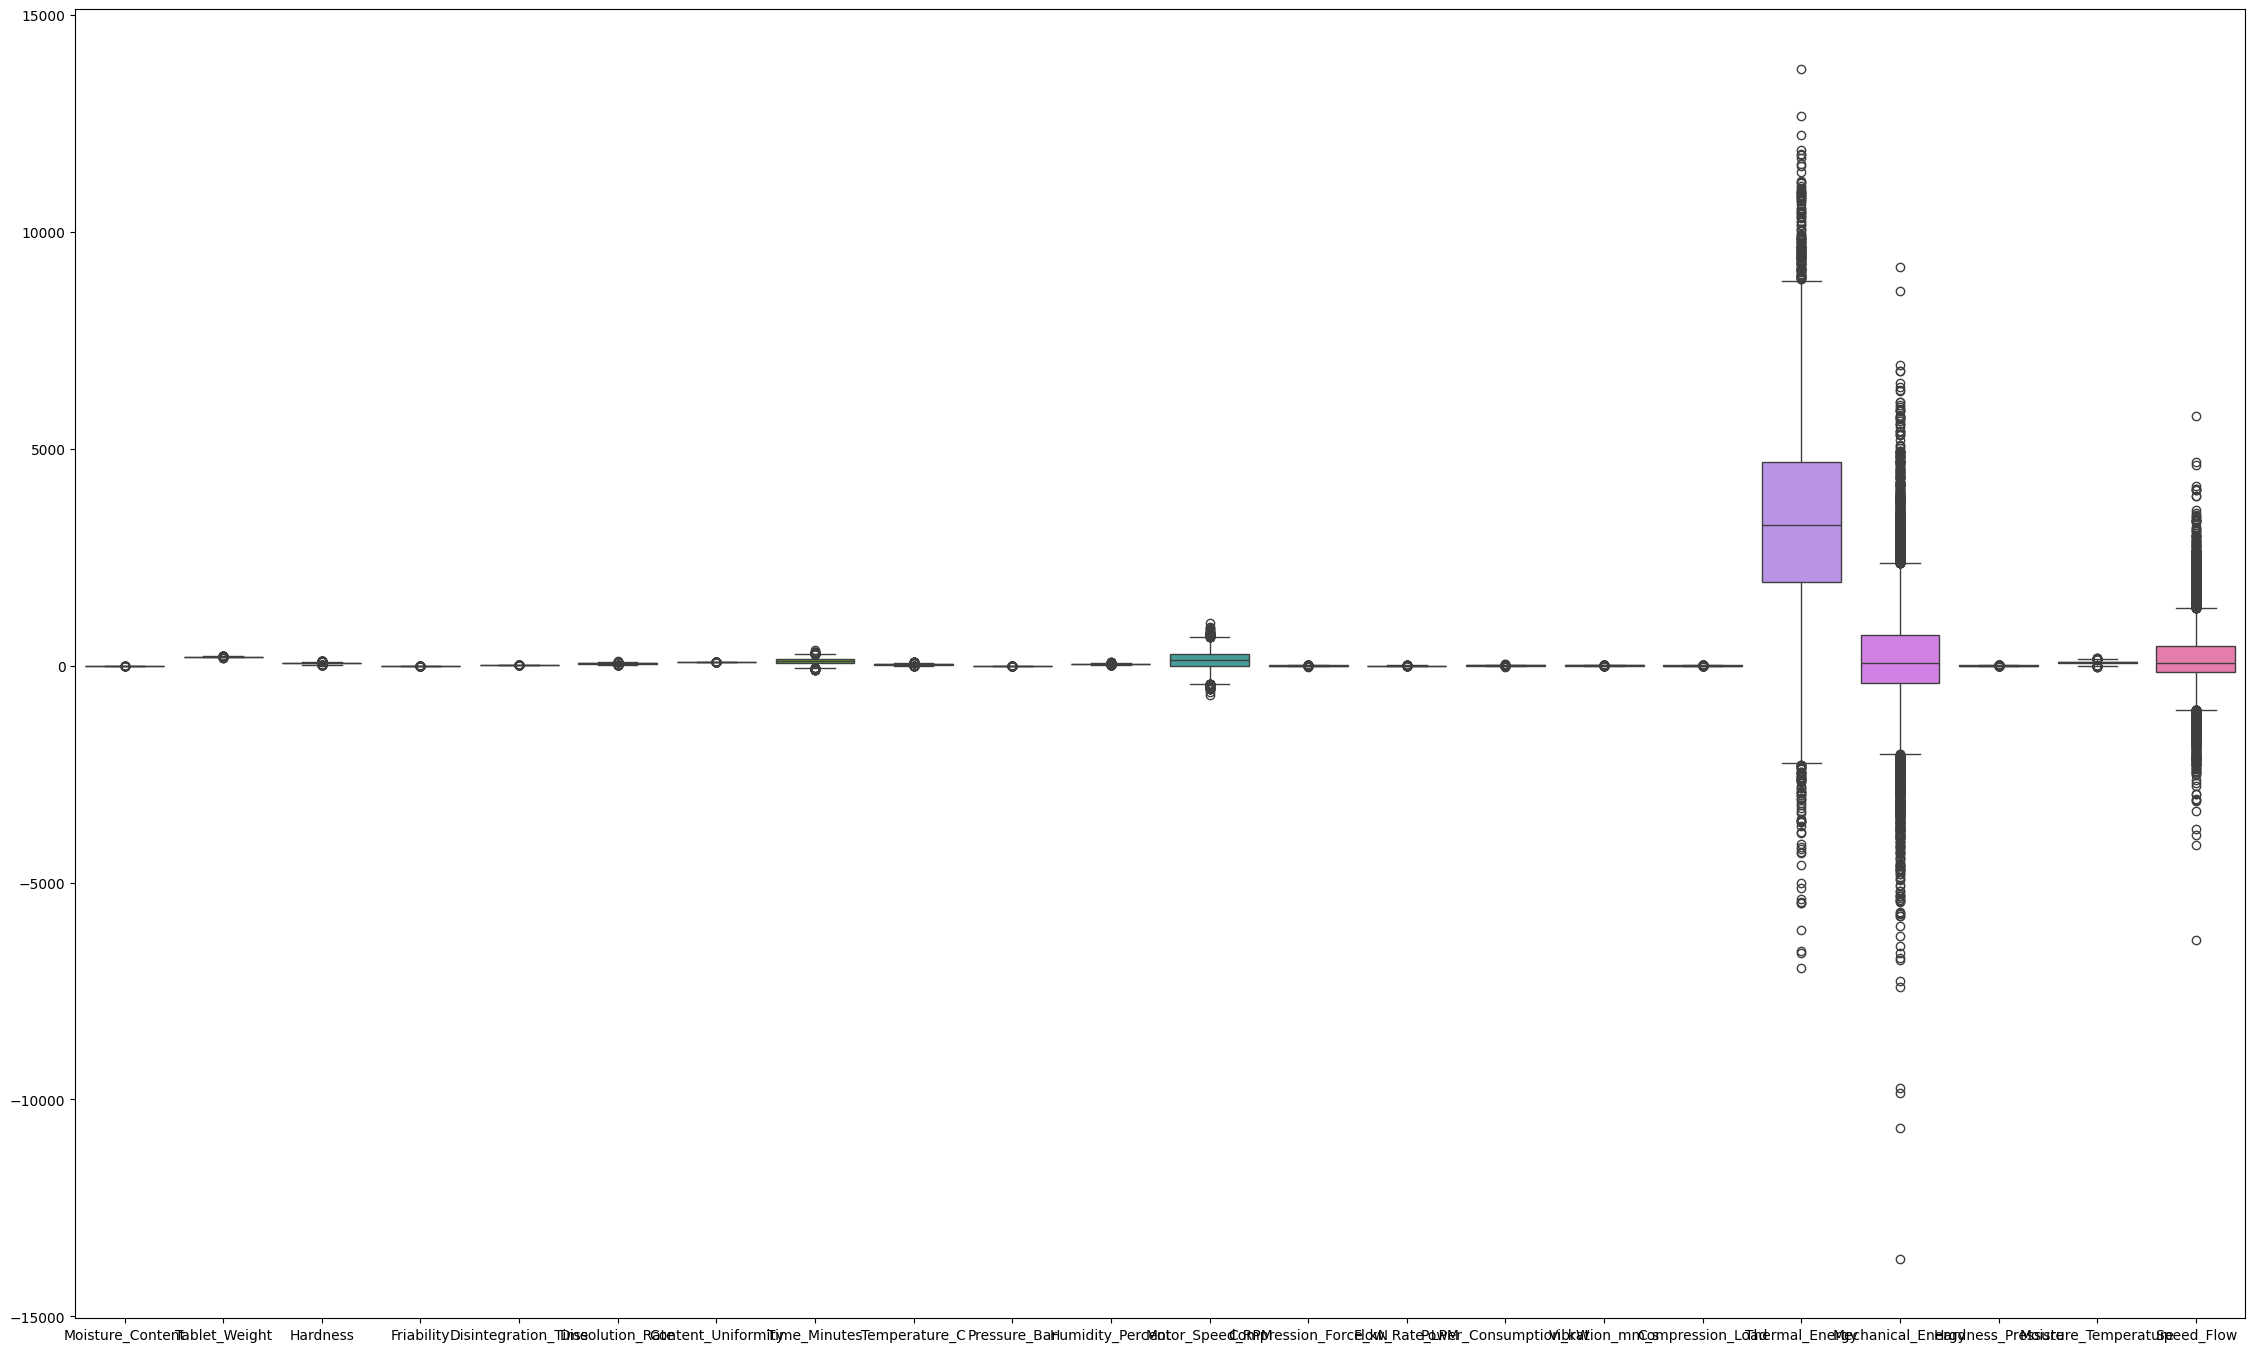

In [49]:
#outliers
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(28,17))
sns.boxplot(augmented_data)

In [50]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [51]:
X_train.shape

(8000, 16)

In [52]:
#Handling Outliers (Robust Scaling)
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [53]:


from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor

models = {
    "RandomForest": MultiOutputRegressor(RandomForestRegressor(random_state=42)),
    "XGBoost": MultiOutputRegressor(XGBRegressor(
        random_state=42,
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.8)),
    "GradientBoosting": MultiOutputRegressor(GradientBoostingRegressor(random_state=42)),
    "SVR": MultiOutputRegressor(SVR())
}

In [54]:
param_grids = {

"RandomForest": {
    "estimator__n_estimators":[200,400,600],
    "estimator__max_depth":[8,12,16],
    "estimator__min_samples_split":[2,5,10],
    "estimator__min_samples_leaf":[1,2,4]
},

"XGBoost": {
    "estimator__n_estimators":[400,600,800],
    "estimator__max_depth":[4,6,8],
    "estimator__learning_rate":[0.03,0.05,0.07],
    "estimator__subsample":[0.8,0.9],
    "estimator__colsample_bytree":[0.7,0.8,0.9],
    "estimator__gamma":[0,0.1,0.2],
    "estimator__reg_lambda":[1,2]
},

"GradientBoosting": {
    "estimator__n_estimators":[200,400,600],
    "estimator__learning_rate":[0.01,0.05,0.1],
    "estimator__max_depth":[3,5,7]
},

"SVR": {
    "estimator__kernel":["rbf"],
    "estimator__C":[10,50,100],
    "estimator__epsilon":[0.01,0.1,0.2]
}
}

In [55]:
#Hyperparameter tuning

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

results = []

for name, model in models.items():

    search = RandomizedSearchCV(
        model,
        param_grids[name],
        n_iter=25,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_

    pred = best_model.predict(X_test)

    r2 = r2_score(y_test, pred)
    mae = mean_absolute_error(y_test, pred)
    rmse = np.sqrt(mean_squared_error(y_test, pred))

    results.append({
        "Model": name,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    })

f:\Coding Stuff\HACKATHON-Project-IIT-H-\.venv\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 9 is smaller than n_iter=25. Running 9 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


In [56]:
results_df = pd.DataFrame(results)

print(results_df.sort_values("R2", ascending=False))

              Model        R2       MAE      RMSE
2  GradientBoosting  0.817524  0.468521  0.677682
1           XGBoost  0.816512  0.414618  0.599011
0      RandomForest  0.815810  0.513310  0.790003
3               SVR  0.747818  1.373671  3.159454


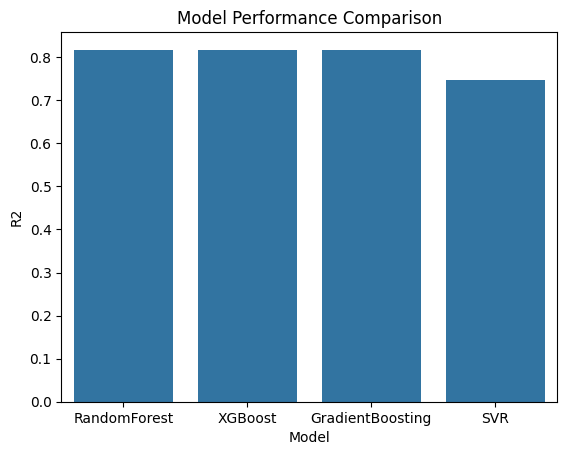

In [70]:
#Performance comparison

import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x="Model", y="R2", data=results_df)

plt.title("Model Performance Comparison")
plt.show()

In [58]:
augmented_data.corr(numeric_only=True)

,Moisture_Content,Tablet_Weight,Hardness,Friability,Disintegration_Time,Dissolution_Rate,Content_Uniformity,Time_Minutes,Temperature_C,Pressure_Bar,...,Compression_Force_kN,Flow_Rate_LPM,Power_Consumption_kW,Vibration_mm_s,Compression_Load,Thermal_Energy,Mechanical_Energy,Hardness_Pressure,Moisture_Temperature,Speed_Flow
Moisture_Content,1.000000,-0.010858,0.005500,-0.001034,0.002217,-0.008780,-0.007806,-0.007195,-0.011002,0.034127,...,0.002214,-0.016426,0.001637,0.005143,0.003665,-0.014148,0.011101,0.003665,-0.011002,0.003117
Tablet_Weight,-0.010858,1.000000,-0.180844,0.201305,-0.617525,0.508401,0.078459,-0.417873,0.894878,-0.292469,...,-0.397422,0.843448,-0.211197,-0.286412,-0.417577,0.160489,0.019216,-0.417577,0.894878,0.608304
Hardness,0.005500,-0.180844,1.000000,-0.906145,0.029413,-0.920086,0.237811,0.119124,-0.248082,-0.037190,...,0.900457,-0.346655,0.925536,0.977602,0.888147,-0.036553,0.552070,0.888147,-0.248082,-0.052565
Friability,-0.001034,0.201305,-0.906145,1.000000,-0.072359,0.857765,-0.428117,-0.247064,0.284544,0.141636,...,-0.834416,0.331168,-0.848102,-0.893209,-0.815294,-0.065443,-0.486831,-0.815294,0.284544,0.072572
Disintegration_Time,0.002217,-0.617525,0.029413,-0.072359,1.000000,-0.329767,-0.097548,0.305724,-0.756998,0.137957,...,0.031097,-0.708662,-0.093942,0.031940,0.042417,-0.180126,0.009030,0.042417,-0.756998,-0.322069
Dissolution_Rate,-0.008780,0.508401,-0.920086,0.857765,-0.329767,1.000000,-0.173699,-0.269865,0.606229,-0.044976,...,-0.862853,0.665250,-0.816438,-0.915861,-0.858427,0.117273,-0.487542,-0.858427,0.606229,0.242956
Content_Uniformity,-0.007806,0.078459,0.237811,-0.428117,-0.097548,-0.173699,1.000000,0.150715,0.054115,-0.209507,...,0.236122,0.089006,0.264792,0.240025,0.218099,0.183185,0.112933,0.218099,0.054115,0.046216
Time_Minutes,-0.007195,-0.417873,0.119124,-0.247064,0.305724,-0.269865,0.150715,1.000000,-0.427532,0.019976,...,0.215337,-0.349559,0.138186,0.166100,0.213492,0.710219,0.014922,0.213492,-0.427532,-0.252641
Temperature_C,-0.011002,0.894878,-0.248082,0.284544,-0.756998,0.606229,0.054115,-0.427532,1.000000,-0.187611,...,-0.309582,0.945513,-0.143137,-0.283579,-0.323440,0.216738,-0.086822,-0.323440,1.000000,0.497547
Pressure_Bar,0.034127,-0.292469,-0.037190,0.141636,0.137957,-0.044976,-0.209507,0.019976,-0.187611,1.000000,...,-0.005218,-0.299055,-0.052894,-0.013231,0.069624,-0.101236,-0.030921,0.069624,-0.187611,-0.169195


In [59]:
# import seaborn as sns
# import matplotlib.pyplot as plt

# plt.figure(figsize=(14,10))

# corr_matrix = augmented_data.corr(numeric_only=True)

# sns.heatmap(
#     corr_matrix,
#     cmap="coolwarm",
#     annot=True,
#     fmt=".2f",
#     linewidths=0.5
# )

# plt.title("Feature Correlation Heatmap")
# plt.show()

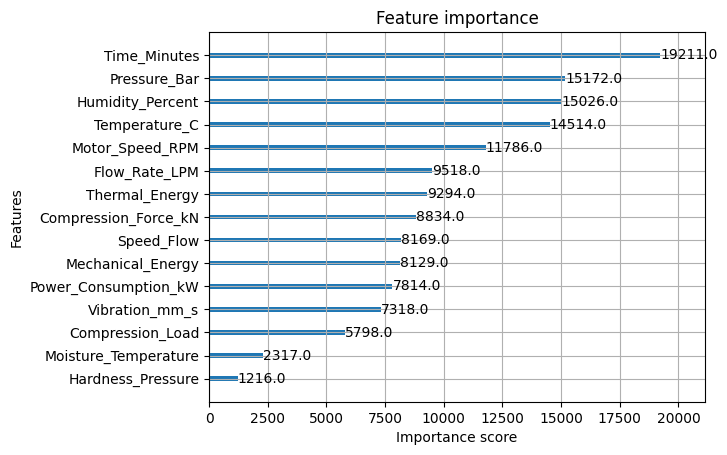

In [72]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plot_importance(model)
plt.show()